In [ ]:
# base
import os
import sys
import gc
import re
import warnings
import logging
import pickle
from time import ctime, time
from datetime import timedelta
from collections import Counter
import itertools
import session_info

# data manipulation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from rpy2.robjects.conversion import localconverter

# single cell
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_plot as sdp
import spatialdata_io

# custom
sys.path.insert(0, '../../..')
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from utils import *

warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.ERROR)

# # R
# import rpy2.robjects as ro
# from rpy2.robjects.conversion import localconverter

# converter = get_converter()
# %load_ext rpy2.ipython

# analysis & device specific
%matplotlib inline
CORES = 10
CORES = 10
DATADIR = Path("../../../../data") / "processed" / "spatial" / "Visium HD" / "analysis"
REFDIR = Path("../../../../references")
mpl.rcdefaults()

/mnt/DATA/home/ethung/projects/spatial_seq/.pixi/envs/main/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.sparse.base import spmatrix


# Load data

In [ ]:
# LOAD
sdata = sd.read_zarr(
    os.path.join(DATADIR, "processed", "spatial", "raws", "COMBINED_RAW")
)

In [ ]:
annotation = "raw_processed-V5 WT_filter70"
adata_sp = sc.read_h5ad(
    os.path.join(DATADIR, "processed", "spatial", "combined", f"{annotation}.h5ad")
)
samples = list(adata_sp.obs["Identifier"].unique())

annotation = "annotated"
adata_sc = sc.read_h5ad(
    os.path.join(
        DATADIR, "processed", "single cell", "5_analysis", f"{annotation}.h5ad"
    )
)

# aucell = sc.read_h5ad(
#     os.path.join(
#         DATADIR, "processed", "spatial", "combined", f"{annotation} AUCELL.h5ad"
#     )
# )

# Exploratory Analysis

### Cluster

In [ ]:
%%time
from sklearn.metrics import silhouette_score

for res in [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]:
    res = 1
    cluster_key = f"leiden_{res:.1f}"
    print(cluster_key)
    sc.tl.leiden(adata_sp, resolution=res, key_added=cluster_key)

In [ ]:
%%time
res = 1.5
cluster_key = f"leiden_{res:.1f}"

f, axs = plt.subplots(
    1, len(samples), figsize=(len(samples) * 6, 6), layout="constrained"
)
for n, id in enumerate(adata_sp.obs["Identifier"].unique()):
    sc.pl.spatial(
        adata_sp[adata_sp.obs["Identifier"] == id],
        color=cluster_key,
        spot_size=150 if n == 0 else 200,
        ax=axs[n],
        show=False,
        palette=color_gen(adata_sp.obs[cluster_key].unique()).to_list(),
        title=id,
    )

In [ ]:
# SAVE
adata_sp.write(
    os.path.join(DATADIR, "processed", "combined", "raw_processed-V5 WT_filter70.h5ad")
)

In [ ]:
# LOAD
adata_sp = sc.read_h5ad(
    os.path.join(DATADIR, "processed", "combined", "raw_processed-V5 WT_filter70.h5ad")
)

### Visualize

In [ ]:
res = 1.5
cluster_key = f"leiden_{res:.1f}"
embedding = "UMAP"

cluster_c = color_gen(adata_sp.obs[cluster_key])
f = plt.figure(figsize=(10, 10), layout="constrained")

axs = f.subplots(3, 2)
gs = axs[0, 0].get_gridspec()
for rs in axs[:]:
    for ax in rs[:]:
        ax.remove()

# Large plot
ax = f.add_subplot(gs[:2, :])
sc.pl.embedding(
    adata_sp,
    basis=embedding,
    color=[cluster_key],
    ax=ax,
    show=False,
    legend_loc="on data",
    legend_fontoutline=2,
    legend_fontsize=20,
    palette=cluster_c.to_list(),
)
# ax = f.add_subplot(gs[2, 0])
# sc.pl.embedding(
#     adata_sp,
#     basis=embedding,
#     color=["Group"],
#     ax=ax,
#     show=False,
#     alpha=0.7,
# )
ax = f.add_subplot(gs[2, 0])
sc.pl.embedding(adata_sp, basis=embedding, color=["Diet"], ax=ax, show=False, alpha=0.7)
ax = f.add_subplot(gs[2, 1])
sc.pl.embedding(
    adata_sp, basis=embedding, color=["Model"], ax=ax, show=False, alpha=0.7
)

In [ ]:
variable_genes = (
    adata_sp.var[adata_sp.var["highly_variable"]].sort_values("highly_variable_rank")
).index
variable_genes

In [ ]:
def plot_violinplot(
    adata,
    markers,
    group: str,
    f,
    layer: str = "normalized",
    useStripPlot=True,
    bracket_params=None,
):
    axs = f.subplots(len(markers), 1)
    for n, m in enumerate(markers):
        sc.pl.violin(
            adata,
            m,
            groupby=group,
            use_raw=False,
            layer=layer,
            show=False,
            ax=axs[n],
            stripplot=useStripPlot,
        )
        if n < len(markers) - 1:
            axs[n].set_xlabel("")
            axs[n].set_xticklabels([""] * len(axs[n].get_xticklabels()))
        axs[n].set_ylabel(axs[n].get_ylabel(), size=12)

    if bracket_params is not None:
        ratios = bracket_params["ratio"] / np.sum(bracket_params["ratio"])
        ends = np.append(0, np.cumsum(ratios))
        bar_label_locs = [ends[i] + ratios[i] / 2 for i in range(len(ratios))]
        bar_bracket_widths = ratios * f.get_size_inches()[0] * 3.1

        axs = f.get_axes()
        for (
            n,
            label,
        ) in enumerate(bracket_params["labels"]):
            axs[-1].annotate(
                label,
                xy=(bar_label_locs[n], -bracket_params["bracket_y"]),
                xytext=(bar_label_locs[n], -bracket_params["label_y"]),
                xycoords="axes fraction",
                ha="center",
                va="bottom",
                bbox=dict(boxstyle="square", fc="none", color="none"),
                arrowprops=dict(
                    arrowstyle=f"-[, widthB={bar_bracket_widths[n]}, lengthB=0.3",
                    lw=1.0,
                    color="k",
                ),
            )
        axs[-1].set_xlabel(axs[-1].get_xlabel(), labelpad=bracket_params["padding"])

    return


f = plt.figure(figsize=(10, 15), layout="constrained")

# markers = [
#     "Adipoq",
#     "Pdgfra",
#     "Upk3b",
#     "Cdh5",
#     "Rgs5",
#     "Adgre1",
#     "Flt3",
#     "Cpa3",
#     "Skap1",
#     "Igkc",
# ]
plot_violinplot(
    adata_sp,
    variable_genes[:20],
    cluster_key,
    f,
    useStripPlot=False,
    layer="normalized",
)

In [ ]:
res = 1.5
cluster_key = f"leiden_{res:.1f}"

sc.tl.rank_genes_groups(
    adata_sp,
    groupby=cluster_key,
    groups=["0"],
    reference=["3"],
    key_added=f"de_temp_0_3",
    use_raw=False,
    layer="normalized",
    method="wilcoxon",
)
df = sc.get.rank_genes_groups_df(adata_sp, group=None, key=f"de_temp_0_3")

In [ ]:
df = df[df.pvals_adj < 0.05]
df[df.group == "3"]

In [ ]:
res = 1.5
cluster_key = f"leiden_{res:.1f}"

sc.tl.rank_genes_groups(
    adata_sp,
    groupby=cluster_key,
    key_added=f"de_{cluster_key}",
    use_raw=False,
    layer="normalized",
    method="wilcoxon",
)

sc.pl.rank_genes_groups_dotplot(
    adata_sp,
    groupby=cluster_key,
    key=f"de_{cluster_key}",
    standard_scale="var",
    n_genes=5,
    min_logfoldchange=2,
)

In [ ]:
res = 1.5
cluster_key = f"leiden_{res:.1f}"

df = sc.get.rank_genes_groups_df(adata_sp, group=None, key=f"de_{cluster_key}")
# threshold = 1e-75
# DEGs_cutoff = df[df["pvals_adj"] < threshold].names.unique()
# print("DEGs under threshold:", len(DEGs_cutoff))

cutoff = 20
topDEGs_df = pd.concat(
    [
        tmp[tmp.pvals_adj < 0.05].nlargest(cutoff, "scores")
        for _, tmp in df.groupby("group")
    ]
)

topDEGs = topDEGs_df.names.unique()

f = plt.figure(figsize=(10, 90), layout="constrained")
plot_violinplot(
    adata_sp,
    topDEGs,
    cluster_key,
    f,
    useStripPlot=False,
    layer="normalized",
)

In [ ]:
sc.pl.violin(adata_sp, keys="Cd5l", groupby="leiden_1.5")

In [ ]:
cutoff = 50
topDEGs_df = pd.concat(
    [
        tmp[tmp.pvals_adj < 0.05].nlargest(cutoff, "scores")
        for _, tmp in df.groupby("group")
    ]
)

topDEGs_df[topDEGs_df["group"] == "12"]

### AUCell for bin assignment

#### Run AUCell

In [ ]:
# Setup
ref_dir = os.path.join(REFDIR, "custom_signatures")

collections = {
    "snRNA_SoEtAl_immuneVstromal": pd.read_csv(
        os.path.join(ref_dir, "snRNA_SoEtAl2025_DEGS-stromal_VS_immune_markers.csv"),
        index_col=0,
    ).rename(columns={"group": "source", "names": "target"}),
    "snRNA_SoEtAl_immune": pd.read_csv(
        os.path.join(ref_dir, "snRNA_SoEtAl2025_DEGS-immune_markers.csv"),
        index_col=0,
    ).rename(columns={"group": "source", "names": "target"}),
    "snRNA_SoEtAl_stromal": pd.read_csv(
        os.path.join(ref_dir, "snRNA_SoEtAl2025_DEGS-stromal_markers.csv"),
        index_col=0,
    ).rename(columns={"group": "source", "names": "target"}),
}

In [ ]:
for name, geneset in collections.items():
    GSEA_decoupler(adata_sp, name, type="AUCell", geneset=geneset, remove_prefix=False)
adata_sp.obsm["snRNA_SoEtAl_stromal_score_aucell"].rename(
    columns={"PC/SMC": "PC-SMC"}, inplace=True
)

adata_sp

In [ ]:
res = 1.5
cluster_key = f"leiden_{res:.1f}"

scores = []
for name, geneset in collections.items():
    score = dc.pp.get_obsm(adata=adata_sp, key=f"{name}_score_aucell")
    sc.pl.embedding(
        score,
        basis="UMAP",
        color=list(geneset.source.unique()) + [cluster_key],
        cmap="Reds",
        # vmax=0.15,
        ncols=2,
        legend_loc="on data",
    )
    scores.append(score)


# f = plt.figure(figsize=(len(collections) * 5, 10), layout="constrained")
# ax = f.subplots(2, len(collections)).flatten()

# for i, cond in enumerate(score.obs["Condition"].unique()):
#     tmp = score[score.obs["Condition"] == cond]
#     for j, coll in enumerate(collections):
#         sc.pl.embedding(
#             tmp,
#             basis="LocalMAP_fibro",
#             color=coll,
#             title=f"{coll}\n({cond} eWAT)",
#             vmax=np.max(score[:, coll].X),
#             ax=ax[i * len(collections) + j],
#             show=False,
#         )

#### Plot

In [ ]:
aucell_sets = [
    dc.pp.get_obsm(adata=adata_sp, key=f"{name}_score_aucell").var_names
    for name, _ in collections.items()
]
aucell_sets = aucell_sets[0].append(aucell_sets[1:])

# aucell = sc.AnnData(
#     X=np.hstack([score.X for score in scores]),
#     obs=score.obs,
#     var=pd.DataFrame(index=aucell_sets),
#     obsm=score.obsm,
# )

sc.pl.matrixplot(
    aucell,
    var_names=aucell_sets,
    groupby=cluster_key,
    dendrogram=True,
    cmap="Reds",
    # vmax=0.15,
    standard_scale="var",
)

sc.pl.heatmap(
    aucell,
    var_names=aucell_sets,
    groupby=cluster_key,
    dendrogram=True,
    cmap="Reds",
    # vmax=0.15,
    standard_scale="var",
)

In [ ]:
groups = [0, 4, 8, 12, 3, 6]
cat1 = "Stromal"
cat2 = "Immune"
cluster_key = "leiden_1.0"

# sns.histplot(aucell.to_df()[category])

sns.histplot(
    aucell[aucell.obs[cluster_key].isin(pd.Series(groups).astype(str))].to_df(),
    x=cat1,
    y=cat2,
    alpha=1,
    label=f"Stromal",
    color="orange",
)

sns.histplot(
    aucell[~aucell.obs[cluster_key].isin(pd.Series(groups).astype(str))].to_df(),
    x=cat1,
    y=cat2,
    alpha=1,
    label=f"Immune",
    color="blue",
)
plt.legend()

In [ ]:
aucell_df = aucell.to_df()
aucell_df["leiden_1.5"] = aucell.obs["leiden_1.5"].copy()
aucell_df = aucell_df.groupby("leiden_1.5").mean()
aucell_df[:] = scipy.stats.rankdata(aucell_df.groupby("leiden_1.5").mean(), axis=0)
aucell_df

In [ ]:
f = plt.figure(figsize=(8, 10), layout="constrained")
plot_violinplot(
    aucell,
    aucell.var_names,
    "leiden_1.5",
    f,
    layer=None,
    useStripPlot=False,
    ylabel_size=10,
)

In [ ]:
# cell type assignment via AUCell?
key = "_AUCell"
neighbor_key = "aucell_neighbors"
res = 2
cluster_key = f"AUCell_leiden{res:.1f}"

runDR = False
runClust = False

if runDR is True:
    Visualize(aucell, key, None, neighbor_key)

if runClust is True:
    print("Starting clustering...")
    sc.tl.leiden(
        aucell, resolution=res, key_added=cluster_key, neighbors_key=neighbor_key
    )
    aucell.layers["original"] = aucell.X.copy()

# Plot
sc.pl.embedding(
    aucell,
    basis="UMAP",
    color=cluster_key,
)

In [ ]:
f = plt.figure(figsize=(10, 20), layout="constrained")
plot_violinplot(aucell, aucell.var_names, "AUCell_clusters", f, layer="original")

In [ ]:
f, ax = plt.subplots(1, 3, figsize=(30, 10), layout="constrained")
sample1 = aucell[aucell.obs["Identifier"] == samples[0]]
sample1_macs = sample1[
    sample1.obs["leiden_1.5"].isin(pd.Series([2, 5, 10]).astype(str))
]
sample1_fbs = sample1[
    sample1.obs["leiden_1.5"].isin(pd.Series([4, 5, 6, 8, 11]).astype(str))
]


sample1_adi = sample1[
    sample1.obs["leiden_1.5"].isin(pd.Series([0, 3, 6, 11]).astype(str))
]

sc.pl.spatial(
    sample1,
    color="leiden_1.5",
    spot_size=100,
    ax=ax[0],
    show=False,
    alpha=0.75,
)

sc.pl.spatial(
    sample1_adi,
    color="leiden_1.5",
    spot_size=100,
    ax=ax[1],
    show=False,
    alpha=0.75,
    palette=create_palette(5),
)

sdata.pl.render_images(f"queried_hires-{samples[0]}").pl.show(
    coordinate_systems=f"{samples[0]}_downscaled_hires", ax=ax[2]
)

In [ ]:
f, ax = plt.subplots(1, 3, figsize=(45, 15), layout="constrained")
sc.pl.spatial(
    aucell[aucell.obs["Identifier"] == samples[0]],
    color="B cell",
    spot_size=100,
    ax=ax[0],
    show=False,
    alpha=0.75,
)

sc.pl.spatial(
    aucell[aucell.obs["Identifier"] == samples[0]],
    color="T cell",
    spot_size=100,
    ax=ax[1],
    show=False,
    alpha=0.75,
)

sc.pl.spatial(
    aucell[aucell.obs["Identifier"] == samples[0]],
    color="Fibroblast",
    spot_size=100,
    ax=ax[2],
    show=False,
    alpha=0.75,
)

### Save/Load ALL

In [ ]:
# SAVE
annotation = "raw_processed-V5 WT_filter70.h5ad"
adata_sp.write(os.path.join(DATADIR, "processed", "combined", annotation))

In [ ]:
# SAVE
annotation = "raw_processed-V5 WT_filter70 AUCELL.h5ad"
aucell.write(os.path.join(DATADIR, "processed", "combined", annotation))

# Test Space

In [10]:
adata = sc.read(DATADIR / "processed" / "spatial" / "analysis" / "30_10-clustered.h5ad")
neighborhoods = pd.read_csv(
    DATADIR
    / "processed"
    / "spatial"
    / "analysis"
    / "final_neighborhoods"
    / "ALL_neighborhoods.csv",
    index_col=0,
)

/tmp/ipykernel_1522828/356192014.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


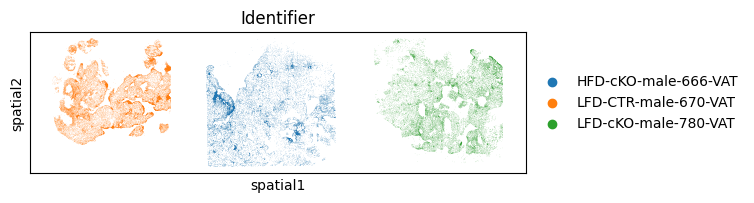

In [11]:
# add spatial separation
adata.obs["x"], adata.obs["y"] = np.hsplit(adata.obsm["spatial"], 2)
samples = adata.obs["Identifier"].unique()

ref = samples[0]
for n in np.arange(1, len(samples)):
    ref = samples[n - 1]
    samp = samples[n]
    ref_adata = adata[adata.obs["Identifier"] == ref].copy()
    new_adata = adata[adata.obs["Identifier"] == samp].copy()

    adata.obs["x"].loc[new_adata.obs_names], adata.obs["y"].loc[new_adata.obs_names] = (
        concat_spatial(
            new_adata.obs["x"],
            new_adata.obs["y"],
            ref_adata.obs["x"],
            ref_adata.obs["y"],
            offset_x=0.3,
        )
    )

adata.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()
sc.pl.spatial(adata, color="Identifier", spot_size=100)

In [12]:
# add neighborhood annotations after subsetting
adata = adata[neighborhoods.index]
for col in neighborhoods.columns:
    adata.obs[col] = neighborhoods[col]

In [13]:
# process adata
adata.X = adata.layers["counts"].copy()
del adata.uns, adata.varm, adata.obsp, adata.var
adata.obsm = {
    k: v for k, v in adata.obsm.items() if k in ["LocalMAP", "UMAP", "spatial"]
}


# convert names
def convert_cellid(s, batches, query=r"cellid_(\d+)-(.+)"):
    match = re.search(query, s)
    cell_num = match.group(1)

    samp_num = None
    for n, i in enumerate(batches):
        if i in match.group(2):
            samp_num = n
            break
    if samp_num is None:
        raise ValueError(f"{s} after {query} does not include any value in {batches}")

    return f"s_002um_0{cell_num[:3]}{samp_num}_{cell_num[4:]}-1"


adata.obs_names = [
    convert_cellid(cell, adata.obs["Identifier"].cat.categories)
    for cell in adata.obs_names
]

# keep specific clusters only
cluster_cols = adata.obs.columns.str.contains(
    "leiden|cellcharter|labels|Identifier", regex=True, case=False
)
adata.obs = adata.obs.loc[:, cluster_cols]

In [18]:
# create cloupe
def create_cloupe(adata: sc.AnnData):
    with ro.conversion.localconverter(get_converter()):
        R_preload()
        ro.globalenv["sce"] = adata
        ro.r(r"library(loupeR)")
        ro.r(r"clust <- as.list(colData(sce)) %>% lapply(as.factor)")
        ro.r(
            r"stopifnot('Projections are not all 2D.' = all(sapply(reducedDims(sce), function(x) is.array(x) && length(dim(x)) == 2)))"
        )
        ro.r(r"proj = reducedDims(sce) %>% as.list()")

        ro.r(r"""
        # print(validate_barcodes(colnames(sce)[1]))
        # print(validate_count_mat(assay(sce, "X")))
        # print(validate_clusters(clust, dim(sce)[2]))
        # print(validate_projections(proj, dim(sce)[2]))
        """)

        ro.r(r"""
        create_loupe(
            assay(sce, "X"),
            clusters = clust, 
            projections = proj,
            output_name = "output",
        )
        """)


create_cloupe(adata)

  
  
  
  
  
  
2025/11/20 01:30:28 validating input file: /tmp/RtmpiBqTyL/file173c8c2ab76ea2.h5
2025/11/20 01:30:32 initializing loupe file: /tmp/1760056448.cloupe
2025/11/20 01:30:32 converting count matrix
2025/11/20 01:30:47 converting projections
2025/11/20 01:30:48 converting clusters
2025/11/20 01:30:50 finished loupe file: /tmp/1760056448.cloupe
2025/11/20 01:30:50 copying loupe file to: output.cloupe


In [ ]:
with ro.conversion.localconverter(get_converter()):
    ro.r(r"""
    print(dim(sce)[2])
    # print(validate_projections(as.list(proj),))
    # print(?validate_projections)
    """)

[1]  14459 103235
